<img src="../assets/coffee_banner.jpg" align="left" width="30%" hspace="20">

<table border="0" cellspacing="0" cellpadding="0" rules="none"><tr><td align="left"><b>
  <font size="7" color="#6B3E26">C </font>
  <font size="7" color="#8B5A2B">O </font>
  <font size="7" color="#A47148">F </font>
  <font size="7" color="#A47148">F </font>
  <font size="7" color="#C08A5A">E </font>
  <font size="7" color="#C08A5A">E </font>
  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
  <font size="7" color="#6B3E26">S </font>
  <font size="7" color="#8B5A2B">U </font>
  <font size="7" color="#A47148">R </font>
  <font size="7" color="#A47148">V </font>
  <font size="7" color="#C08A5A">E </font>
  <font size="7" color="#C08A5A">Y </font><br>
  <font size="7" color="#9C2D63">D A T A &nbsp;&nbsp;A N A L Y S I S </font>
</b>
</td></tr></table>
<p>
<font size="3">
  This project analyzes an international <b>coffee survey</b> using <b>PYTHON, PANDAS,</b> and <b>Matplotlib</b>.<br>
</font>
</p>
<p>
<font size="3">
  <b>Dataset: Public Major Coffee Survey from James Hoffmann</b> <a href="https://www.youtube.com/watch?v=U489K2t_Tgc" target="_blank">
  "Great American Taste Test" </a> <i>(58 questions- 4,042 participants. Mixed data types: categorical, ranges, multi-value, single-value, ordinal)</i>
  <br>
  <b>Purpose:</b>
  <br>
  ■ Demonstrate <b>data cleaning</b>, <b>preprocessing</b> techniques and <b>missing values</b> treatment on a real big dataset with mixed data types.<br>
  ■ <b>EDA</b>: Perform <b>Exploratory Data Analysis</b> skills while exploring coffee consumption habits and patterns.<br>
  ■ Identify <b>CONSUMER PROFILES</b> based on habits, consumption, spending and preferences.<br>
  ■ Apply <b>Python programming</b>, <b>Pandas</b>, <b>regex</b> and <b>Matplotlib</b> skills <br>
</font>
</p>
<table width="100%" bgcolor="#000000" align="center">
  <tr width="100%" bgcolor="#000000"><td width="100%" align="center" bgcolor="#000000">
  <center>
  <font size="4" color="#A247F3FF"><b>
  <br>
    Being PROGRAMMER and COFFEE LOVER like many other programmers,<br> I choose this project to combine my PASSION for CODING <br>with exploring coffee consumption habits through DATA ANALYSIS <br><br>
  </b></font>
  </center>
  </tr></td>
</table>

**NOTE:** <br> the function ***show_df(df)*** displays ALL records from a dataframe.<br>
Use "head" and/or "tail" to limit output if needed, *for example:* ***show_df(df, head=20, tail=40)***. <br> Feel free to uncomment the #show_df() lines to peek outputs.

## 1 . ENVIROMENT SETUP, DATA LOAD <br>   AND INITIAL DATA EXPLORATION

In [1]:
import sys, os
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

import matplotlib.pyplot as plt

in_colab = "google.colab" in sys.modules
if in_colab:
  if not os.path.exists("/content/coffee_survey"):
    print("Project Directory does not exist. Cloning Repository")
    !git clone https://github.com/briella-codes/coffee_survey.git
  else:
    print("Project Directory already exist. Skipping clone")
  %cd /content/coffee_survey
  !ls
  ROOT_DIR = Path("/content/coffee_survey")
else:
  ROOT_DIR = Path().resolve().parents[0]


print("root dir:", ROOT_DIR)
sys.path.append(str(ROOT_DIR))
sys.path.append('/content/coffee_survey/src/')

#IMPORT CUSTOM MODULES/FUNCTIONS:
from src.utils import             (                                             # type: ignore
                                  load_data, create_csv,                     
                                  show_df, summary,
                                  display_horizontal,
                                  print_title, print_subtitle,
                                  print_text, print_observation,
                                  save_pickle
                                  ) 
from src.preprocessing import     (                                             # type: ignore
                                  standardize_columns,                       
                                  simplevalue_str_columns, int_value_columns,
                                  split_multivalue_columns,
                                  set_ordinal_categories,
                                  missing_data_count
                                  )
from src.analysis import          (                                             # type: ignore
                                  group_and_count,
                                  calculate_percentage_by_group
                                  )
from src.visualization import     (PIE_PALETTE,                                 # type: ignore
                                  missing_values_bar_chart,
                                  graphic_pie_chart,
                                  graphic_horizontal_bar_chart,
                                  grouped_bar_chart_fav_coffee_by_age
                                  )

# SETTING DISPLAY :
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.colheader_justify', 'left')

root dir: D:\PORTFOLIO\coffee_survey


In [2]:
#DATA LOAD FROM A CSV FILE AND INITIAL DATA EXPLORATION:
print_subtitle("INITIAL DATA EXPLORATION:")
survey_df = load_data('data/raw/coffee_survey_enriched.csv')
survey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 59 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Submission Id                 4042 non-null   str  
 1   Age                           4042 non-null   str  
 2   Cups                          4042 non-null   str  
 3   Where Drink?                  4042 non-null   str  
 4   Brew                          4042 non-null   str  
 5   Brew Other                    4042 non-null   str  
 6   Purchase                      4042 non-null   str  
 7   Purchase Other                4042 non-null   str  
 8   Favorite                      4042 non-null   str  
 9   Favorite Specify              4042 non-null   str  
 10  Additions                     4042 non-null   str  
 11  Additions Other               4042 non-null   str  
 12  Dairy                         4042 non-null   str  
 13  Sweetener                     4042 non-null 

### RAW DATA PREVIEW
Preview of the first rows of a few columns. To solve: columns names format, NA, empty fields, "None"s that should be string valid answers and shouldnt be treated as nulls, multivalues columns that should should be splited and converted to list (a few of them has comma's exceptions that are part of string answers, so we cant just use sep="," we should use regex) and a few columns it would be better to be converted to ordinal Categorical Columns (Strength,Roast Level, Age, Cups,Number Children)

In [3]:
#DATAFRAME PREVIEW: show_df(df) displays ALL records-you can customize columns to display in the show_df() parameters
# you can Use head and/or tail parameters to limit output if needed. Example: show_df(df, head=20, tail=40)
show_df(survey_df[['Age','Cups','Additions','Roast Level','Favorite','Taste?','Household Income','Number Children','Strength']], head=40 )

,Age,Cups,Additions,Roast Level,Favorite,Taste?,Household Income,Number Children,Strength
0,18-24 years old,NA,No - just black,NA,Regular drip coffee,NA,,NA,NA
1,25-34 years old,NA,"Sugar or sweetener, No - just black",NA,Iced coffee,NA,,NA,NA
2,25-34 years old,NA,No - just black,NA,Regular drip coffee,NA,,NA,NA
3,35-44 years old,NA,"No - just black, Cinnamon",NA,Iced coffee,NA,,NA,NA
4,25-34 years old,NA,No - just black,NA,Latte,NA,,NA,NA
5,55-64 years old,NA,Half & half,NA,Iced coffee,NA,,NA,NA
6,18-24 years old,NA,No - just black,NA,Pourover,NA,,NA,NA
7,NA,NA,NA,NA,NA,NA,,NA,NA
8,25-34 years old,Less than 1,No - just black,NA,Regular drip coffee,NA,,NA,NA
10,18-24 years old,NA,NA,NA,NA,NA,,NA,NA


## 2 . DATA PREPROCESSING
#### DATA CLEANING: Columns names standardization, data type correction (strings, ints, ordinal categories...), multi-values columns transformed into lists, regex filtering, "NA" and missing values converted to proper null values and creation of a csv file "coffee_survey_data_processed_clean.csv" with all de columns values processed 

In [4]:
#column names: remove spaces,"-" , "?" and convert all to low case
survey_df = standardize_columns(survey_df)

#TYPE CONVERSION - Column classification by desired type :
# INT, STRING, LIST, and ORDERED CATEGORICAL:

# Ordinal Columns / Scores - numeric ratings from the consumers:
columns_to_int =    ['expertise','coffee_a_bitterness','coffee_a_acidity','coffee_a_personal_preference','coffee_b_bitterness',
                    'coffee_b_acidity','coffee_b_personal_preference','coffee_c_bitterness','coffee_c_acidity','coffee_c_personal_preference',
                    'coffee_d_bitterness','coffee_d_acidity','coffee_d_personal_preference']

# Single-value STRING columns:
# free text and  opinions, and future 'ordinal categorical' that require preprocessing before type conversion:
columns_to_str =    ['submission_id', 'gender','favorite','favorite_specify', 'brew_other','style','purchase_other','additions_other',
                    'caffeine','roast_level','strength','coffee_a_notes','coffee_b_notes','coffee_c_notes','coffee_d_notes','prefer_abc',
                    'prefer_ad','prefer_overall','wfh', 'why_drink_other','taste','know_source','value_cafe','value_equipment','gender_specify',
                    'most_paid','most_willing','spent_equipment','total_spend','number_children','education_level','ethnicity_race',
                    'ethnicity_race_specify','employment_status','political_affiliation', 'household_income', 'marital_status']

#Multi-value Columns (string columns where the commas separate multiple choise responses):
columns_to_split =  ['where_drink','additions', 'brew','purchase','dairy','sweetener','why_drink']

# Categorical Ordinal Columns:
# keys are column names and the lists represent the values(categories from lowest to highest): 
categorical_ordinal_config = {
    "age" :         ['<18 years old','18-24 years old','25-34 years old','35-44 years old','45-54 years old','55-64 years old','>65 years old'],
    "cups" :        ['Less than 1', '1', '2', '3','4', 'More than 4'],
    "strength" :    ['Weak','Somewhat light','Medium','Somewhat strong','Very strong'],
    "roast_level" : ['Nordic', 'Blonde', 'Light', 'Medium', 'Dark', 'French', 'Italian'],
    "caffeine" :    [ 'Decaf', 'Half caff', 'Full caffeine' ],
    "most_paid" :   ['Less than $2','$2-$4','$4-$6','$6-$8','$8-$10','$10-$15','$15-$20','More than $20'],
    "most_willing": ['Less than $2','$2-$4','$4-$6','$6-$8','$8-$10','$10-$15','$15-$20','More than $20'],
    "spent_equipment" : ['Less than $20','$20-$50','$50-$100','$100-$300','$300-$500','$500-$1000','More than $1,000'],
    "total_spend" :     ['<$20', '$20-$40', '$40-$60', '$60-$80', '$80-$100', '>$100'],
    "number_children" : ['None', '1','2','3', 'More than 3'],
    "household_income": ['Under $25,000','$25,000 - $49,999','$50,000 - $74,999','$75,000 - $99,999','$100,000 - $149,999','$150,000 or more']
}
#Patters for multi-values columns exceptions
#additions tiene una excepción en un valor donde hay una coma como parte de una de las respuestas, por lo que NO se puede hacer split tradicional con sep ="," 
patterns = {'additions' : r", (?=[A-Z])"}
#a few exceptions more: (pending to do -> protect the exception's values)
survey_df['sweetener'] = survey_df['sweetener'].str.replace("e.g.,","e.g.", regex=False)
survey_df['purchase'] = survey_df['purchase'].str.replace("e.g. Starbucks,","e.g. Starbucks /", regex=False)

#Data processing:
survey_df = simplevalue_str_columns(survey_df, columns_to_str)

survey_df = split_multivalue_columns(survey_df, columns_to_split, col_patterns = patterns)
survey_df = int_value_columns(survey_df,columns_to_int)
survey_df = set_ordinal_categories(survey_df, categorical_ordinal_config)

#New files created (.csv and .pkl) with all the processed data:
create_csv(survey_df,"coffee_survey_data_processed.csv")
save_pickle(survey_df,"coffee_survey_data_processed.pkl")

File saved: D:\PORTFOLIO\coffee_survey\data\processed\coffee_survey_data_processed.csv


## 3 . MISSING VALUES ANALYSIS
##### Columns with missing data identified and quantified. <br> Columns with percentage of missing values > "min_percentage" visualization, highest % rates flagged for possible future removal

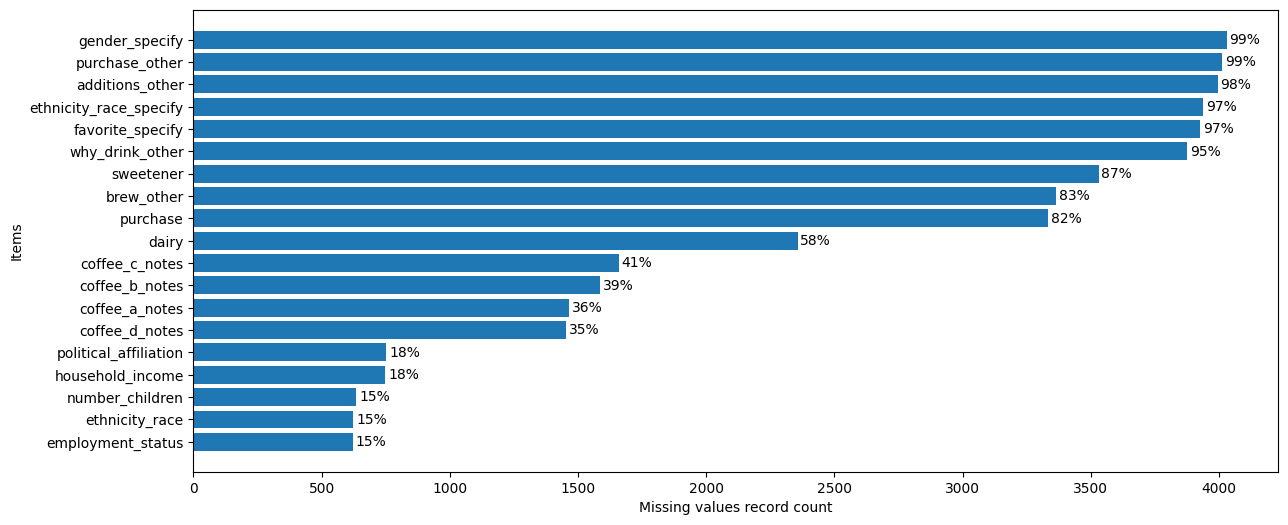

In [5]:
#if you want you can change this 'min_percentage' number here:
min_percentage = 15
print_subtitle("Analysis of Items with missing values percentage > "+str(min_percentage))

fig, ax = plt.subplots(figsize=(14,6))

missing_values_bar_chart(ax,missing_data_count(survey_df,min_percentage))

plt.show()

print_observation("ANALYSIS AND CONCLUSION ON MISSING VALUES: We can see that only a few columns have more than 95% missing values (columns like “other” or “specify” with free-text strings, which for the purpose of this project are mostly irrelevant, so they will be removed for EDA). It can also be observed that this is completely normal—as happens in many long surveys, people tend to drop off midway or lose interest (for example, when questions become repetitive, like in sweetener/dairy), or when they are asked about information they often don’t actually know. Even so, the dataset still reaches the final questions with a relatively low percentage of missing responses, and the core consumption columns (favorite, strength, roast_level, additions, brew) show low missing rates. Overall, it can be considered an analytically valuable dataset.")

## 4 . DATA CLEANING 
#### Column filtering, irrelevant and high missing values columns dropped and final cleand dataset exported to a CSV file "coffee_survey_data_processed_EDA.csv' in /data/processed/ directory. (Uncomment to see processed data dataframe info()):

In [6]:
columns_to_remove = ['favorite_specify','purchase_other','additions_other','coffee_a_notes','coffee_b_notes','coffee_c_notes','coffee_d_notes','gender_specify','ethnicity_race_specify','political_affiliation','ethnicity_race']
survey_df_eda = survey_df.copy()
survey_df_eda = survey_df_eda.drop(columns=columns_to_remove)
create_csv(survey_df_eda,"coffee_survey_data_processed_EDA.csv")
save_pickle(survey_df_eda,"coffee_survey_df_eda.pkl")

#uncomment to see the new dataframe's info:
#survey_df_eda.info()

File saved: D:\PORTFOLIO\coffee_survey\data\processed\coffee_survey_data_processed_EDA.csv


### DATA READY FOR DATA ANALYSIS - PROCESSED DATA PREVIEW :

In [7]:
# Note: show_df(df) displays ALL records. Use "head" and/or "tail" to limit output if needed, for example: show_df(df, head=20, tail=40).
show_df(survey_df[['age','cups','additions','roast_level','favorite','taste','household_income','number_children','strength']], head=10, tail=10 )

,age,cups,additions,roast_level,favorite,taste,household_income,number_children,strength
0,18-24 years old,NaN,('No - just black'),NaN,Regular drip coffee,<NA>,NaN,NaN,NaN
1,25-34 years old,NaN,"('Sugar or sweetener', 'No - just black')",NaN,Iced coffee,<NA>,NaN,NaN,NaN
2,25-34 years old,NaN,('No - just black'),NaN,Regular drip coffee,<NA>,NaN,NaN,NaN
3,35-44 years old,NaN,"('No - just black', 'Cinnamon')",NaN,Iced coffee,<NA>,NaN,NaN,NaN
4,25-34 years old,NaN,('No - just black'),NaN,Latte,<NA>,NaN,NaN,NaN
5,55-64 years old,NaN,('Half & half'),NaN,Iced coffee,<NA>,NaN,NaN,NaN
6,18-24 years old,NaN,('No - just black'),NaN,Pourover,<NA>,NaN,NaN,NaN
7,NaN,NaN,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN
8,25-34 years old,Less than 1,('No - just black'),NaN,Regular drip coffee,<NA>,NaN,NaN,NaN
4032,25-34 years old,1,('No - just black'),Light,Pourover,Yes,"$75,000 - $99,999",None,Somewhat strong


## 5 . **EDA** (EXPLORATORY DATA ANALYSIS)

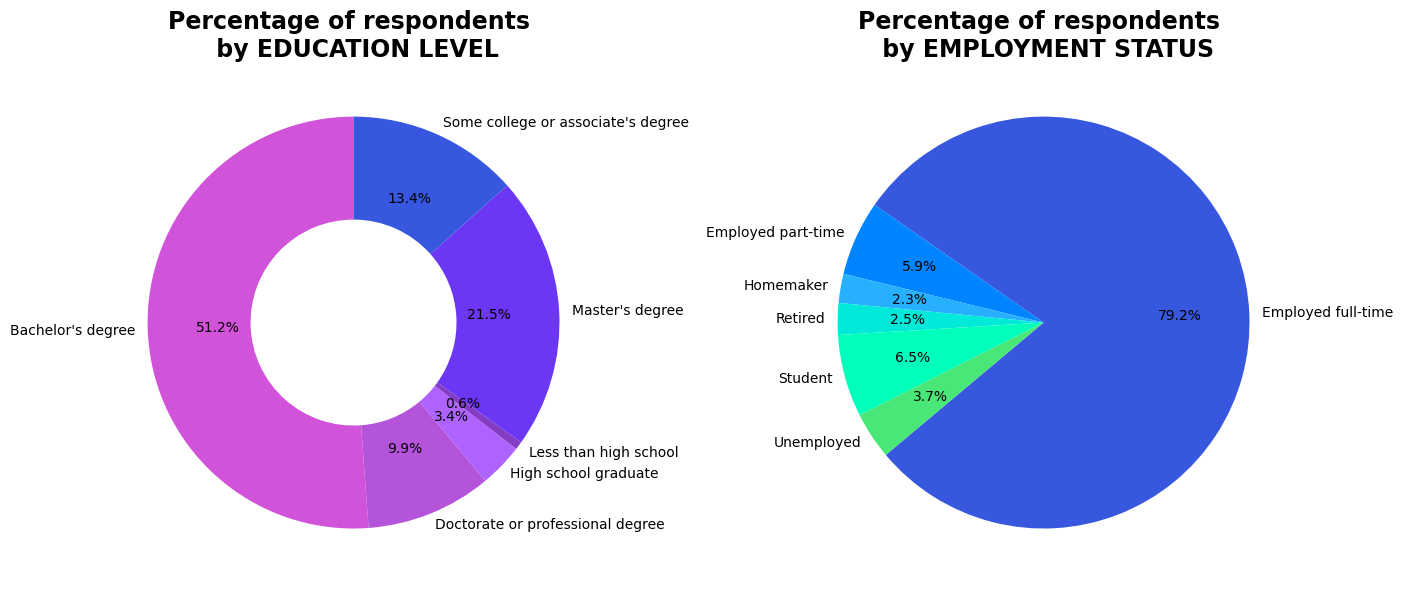

In [8]:
print_title("CONSUMERS DEMOGRAPHIC OVERVIEW")
print_subtitle("Total respondents: "+str(len(survey_df_eda)))

count_by_age_gender = group_and_count(survey_df_eda,'age','gender').reset_index(name='count')
#gender_age_title ="PERCENTAGE OF RESPONDENTS grouped by GENDER AND AGE<br><sup>Interactive chart - click on gender segments to see age breakdown</sup>"

#fig_gender_age = graphic_multilevel_pie_chart(count_by_age_gender,['gender','age'], 'count',gender_age_title,color=[PIE_PALETTE[4],PIE_PALETTE[1]]+PIE_PALETTE[7:])
#fig_gender_age.show()

count_by_education_level = group_and_count(survey_df_eda,'education_level')
count_by_employment_status = group_and_count(survey_df_eda,'employment_status')

fig, (ax1_education,ax2_employment) = plt.subplots(1,2,figsize=(14,6))

ax1_title ="Percentage of respondents \n by EDUCATION LEVEL"
ax2_title = "Percentage of respondents \n by EMPLOYMENT STATUS"

graphic_pie_chart(ax1_education,count_by_education_level,ax1_title,angle=90,shape="donut")
graphic_pie_chart(ax2_employment,count_by_employment_status,ax2_title,angle=220,color=PIE_PALETTE[5:len(count_by_employment_status.values)+5])

plt.tight_layout()
plt.show()

In [9]:
print_title("TOP 5 FAVORITE COFFEES")
top_fav_coffees = group_and_count(survey_df_eda,"favorite").sort_values( ascending=False).head(5)
top_fav_coffees.name="Consumers"

summary(top_fav_coffees, show="display")

,Consumers
favorite,
Pourover,1084
Latte,680
Regular drip coffee,442
Cappuccino,341
Espresso,330


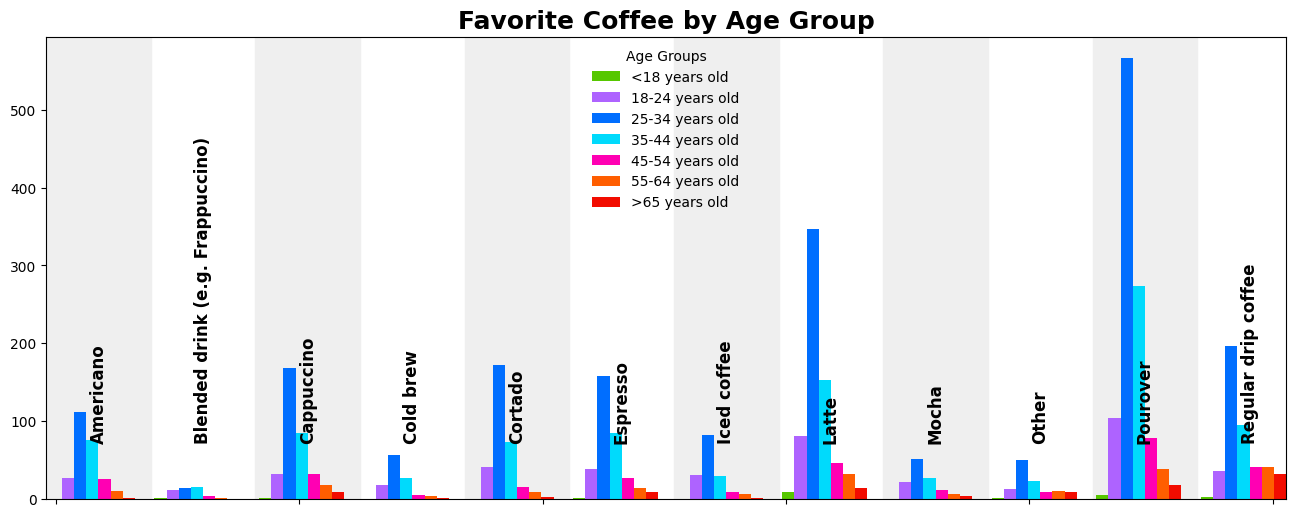

In [10]:
print_title("GROUPED BAR CHART of <br> FAVORITE COFFEE by AGE:")
fav_coffee_by_age = survey_df_eda.groupby(['age','favorite'], observed=True).size()
fav_coffee_by_age = (fav_coffee_by_age.unstack(fill_value=0))

fig, ax_fav_age = plt.subplots(figsize=(16,6))
grouped_bar_chart_fav_coffee_by_age(ax_fav_age,fav_coffee_by_age.T)

plt.show()

Note: For these survey question (Why do you drink coffee?) multiple answer selection was allowed


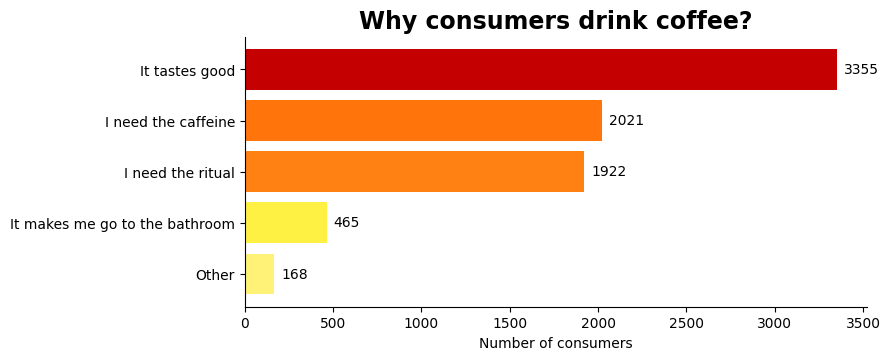

,age,gender,taste,favorite,why_drink_other
128,25-34 years old,Male,No,Blended drink (e.g. Frappuccino),I don't
212,45-54 years old,Female,Yes,Americano,"Comforting, warmth"
364,25-34 years old,Male,Yes,Latte,Fun and devirse
393,35-44 years old,Female,Yes,Latte,Support local business
444,25-34 years old,Male,Yes,Pourover,My wife and I are both coffee professionals
447,45-54 years old,Male,Yes,Latte,I like hanging out in coffee shops
559,25-34 years old,Male,Yes,Espresso,It sparks joy
600,25-34 years old,Male,Yes,Cortado,It smells nice
627,25-34 years old,Non-binary,Yes,Iced coffee,"Nostalgia, comfort"
632,25-34 years old,Male,Yes,Pourover,interesting to explore


In [11]:
print_title("WHY CONSUMERS DRINK COFFEE??")
print("Note: For these survey question (Why do you drink coffee?) multiple answer selection was allowed")

count_by_why_drink = group_and_count(survey_df_eda,"why_drink").sort_values(ascending=True)
fig, ax_why = plt.subplots(figsize=(9,3))
ax_xy_labels = ("Number of consumers","")

graphic_horizontal_bar_chart(ax_why,count_by_why_drink,"Why consumers drink coffee?",ax_xy_labels)
plt.tight_layout()
plt.show()

print_subtitle("Other reasons why consumers drink coffee:")
df_other_why = survey_df_eda[survey_df_eda['why_drink_other'].notna()]
show_df(df_other_why[['age','gender','taste','favorite','why_drink_other']].head(20))

In [12]:
print_title("CONSUMER COUNT BY <br> COFFEE STRENGTH AND DAILY CUPS")

count_by_strength_cups = group_and_count(survey_df_eda,'strength','cups')
summary(count_by_strength_cups, show="display")

Note: For these survey question (brew methods used at home?) multiple answer selection was allowed


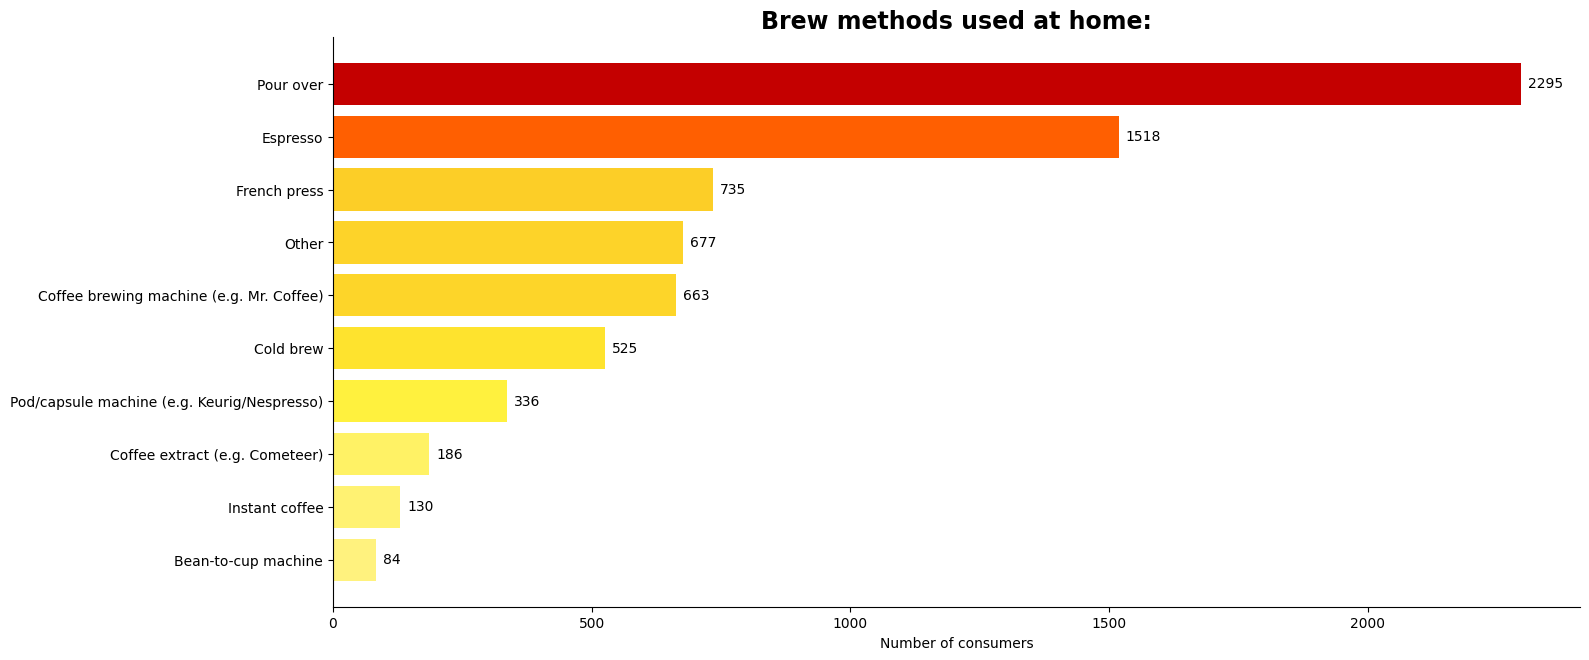

,High Expertise Preferred Brews,count,%
1,Pour over,466,79.3%
2,Espresso,366,62.2%
3,French press,123,20.9%
4,Other,91,15.5%
5,Coffee brewing machine (e.g. Mr. Coffee),89,15.1%
,Medium Expertise Preferred Brews,count,%
1,Pour over,1642,63.9%
2,Espresso,1037,40.3%
3,French press,532,20.7%
4,Other,508,19.8%


In [13]:
print_title("BREWS METHODS USED AT HOME")
print("Note: For these survey question (brew methods used at home?) multiple answer selection was allowed")
count_by_brew_method = group_and_count(survey_df_eda,"brew").sort_values(ascending=True)
fig, ax_brew = plt.subplots(figsize=(16,6))
ax_xy_labels = ("Number of consumers","")
graphic_horizontal_bar_chart(ax_brew,count_by_brew_method,"Brew methods used at home:",ax_xy_labels)
plt.tight_layout()
plt.show()

print_subtitle("Comparing TOP 5<br> BREWS METHODS used at HOME for<br> High vs Medium vs Low EXPERTISE consumers")

high_expertise_consumers = survey_df_eda[survey_df_eda["expertise"]>=8]
medium_expertise_consumers = survey_df_eda[(survey_df_eda["expertise"]<8) & (survey_df_eda["expertise"]>=4)]
low_expertise_consumers = survey_df_eda[survey_df_eda["expertise"]<=3]
high_expertise_top_brews = calculate_percentage_by_group(high_expertise_consumers,"brew",group_title="High Expertise Preferred Brews",sort="desc").head(5)
medium_expertise_top_brews = calculate_percentage_by_group(medium_expertise_consumers,"brew",group_title="Medium Expertise Preferred Brews",sort="desc").head(5)
low_expertise_top_brews = calculate_percentage_by_group(low_expertise_consumers,"brew",group_title="Low Expertise Preferred Brews",sort="desc").head(5)

#function "summary()" by default returns a HTML pretty format type 
display_horizontal(summary(high_expertise_top_brews, notes=True),summary(medium_expertise_top_brews,notes=True),summary(low_expertise_top_brews,notes=True))

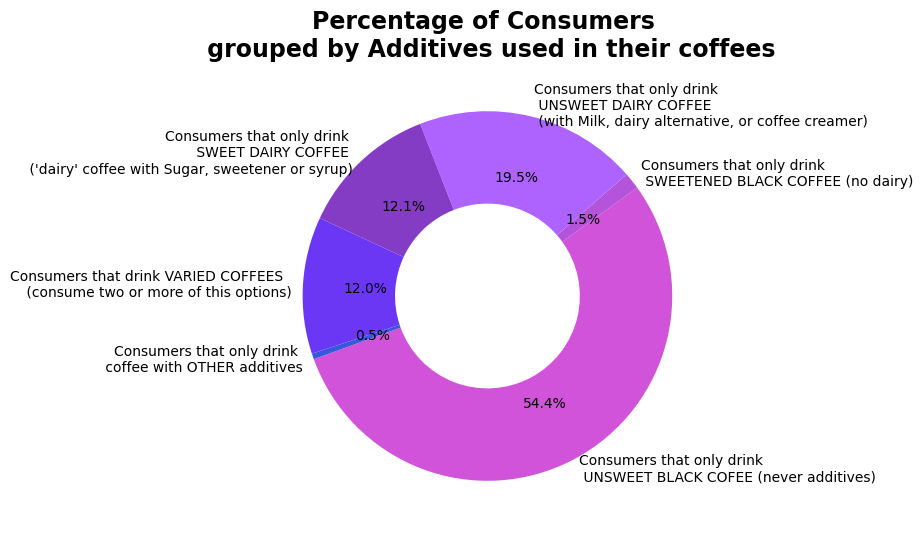

In [14]:
print_title("ANALYSIS OF COFFEE ADDITIVES PREFERENCES : ")
#print("Note: For these survey questions (additions, sweeteners and dairies) multiple answer selection was allowed")

just_black_consumers = survey_df_eda[
                                    (survey_df_eda["additions"].apply(lambda x: (isinstance(x, tuple))
                                    and ("No - just black" in x) and (len(x)==1) ) )
                                    ]

black_sweet_consumers = survey_df_eda[
                                    (survey_df_eda["additions"].apply(lambda x: (isinstance(x, tuple))
                                    and set(x).issubset({"Sugar or sweetener","Flavor syrup"})
                                    and (1<=len(x)<=2) ) )
                                    ]

only_dairy_consumers = survey_df_eda[
                                    (survey_df_eda["additions"].apply(lambda x: (isinstance(x, tuple))
                                    and ("Milk, dairy alternative, or coffee creamer" in x) and (len(x)==1) ) )
                                    ]

dairy_sweet_consumers = survey_df_eda[
                                    (survey_df_eda["additions"].apply(lambda x: (isinstance(x, tuple))
                                    and ("Milk, dairy alternative, or coffee creamer" in x)                            
                                    and (set(x)-{"Milk, dairy alternative, or coffee creamer"}).issubset({"Sugar or sweetener","Flavor syrup"})
                                    and (2<=len(x)<=3) ))
                                    ]

other_additives_consumers = survey_df_eda[
                                    (survey_df_eda["additions"].apply(lambda x: (isinstance(x, tuple)) and ("Other" in x) and (len(x)==1) ) )
                                    ]

concat_additive_groups = pd.concat([just_black_consumers,black_sweet_consumers,only_dairy_consumers,dairy_sweet_consumers,other_additives_consumers])

varied_preference_consumers = survey_df_eda[~((survey_df_eda.index).isin(concat_additive_groups.index))]
varied_preference_consumers = varied_preference_consumers[varied_preference_consumers["additions"].notnull()]

consumers_additive_groups_dfs= {
    "Only Black Coffee" : [just_black_consumers,"Consumers that only drink \n UNSWEET BLACK COFEE (never additives)"],
    "Only Black Coffee sweetened" : [black_sweet_consumers,"Consumers that only drink \n SWEETENED BLACK COFFEE (no dairy)"],
    "Only Dairy Coffee" :[only_dairy_consumers,"Consumers that only drink \n UNSWEET DAIRY COFFEE \n (with Milk, dairy alternative, or coffee creamer)"],
    "Only Sweet Dairy Coffee" : [dairy_sweet_consumers,"Consumers that only drink \n SWEET DAIRY COFFEE \n ('dairy' coffee with Sugar, sweetener or syrup)"],
    "Varied-preference" : [varied_preference_consumers,"Consumers that drink VARIED COFFEES  \n (consume two or more of this options)"],
    "Other additives":[other_additives_consumers,"Consumers that only drink \n coffee with OTHER additives"]
}
count_by_additive_groups = pd.Series( {val[1]: len(val[0]) for val in consumers_additive_groups_dfs.values()} )

fig, ax_additives = plt.subplots(figsize=(14,6))
ax_title ="Additives: Single Preference Consumers vs Flexible Consumers"

graphic_pie_chart(ax_additives,count_by_additive_groups,"Percentage of Consumers \n grouped by Additives used in their coffees",angle=200, shape="donut")
plt.show()